# Breast Cancer Wisconsin - CLASIFICACIÓN

## Objetivo
Construir un modelo de clasificación binaria (benigno/maligno)



In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

cols=['sample_code_number','clump_thickness','uniformity_cell_size','uniformity_cell_shape','marginal_adhesion','single_epithelial_cell_size','bare_nuclei','bland_chromatin','normal_nucleoli','mitoses','class']
df = pd.read_csv('breast-cancer-wisconsin.data', names=cols, na_values='?')
print('Dataset cargado')
df.head()


Dataset cargado


,sample_code_number,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2


In [27]:
print('Shape:', df.shape)
missing=df.isnull().sum()
display(missing[missing>0].to_frame('missing_count'))


Shape: (699, 11)


,missing_count
bare_nuclei,16


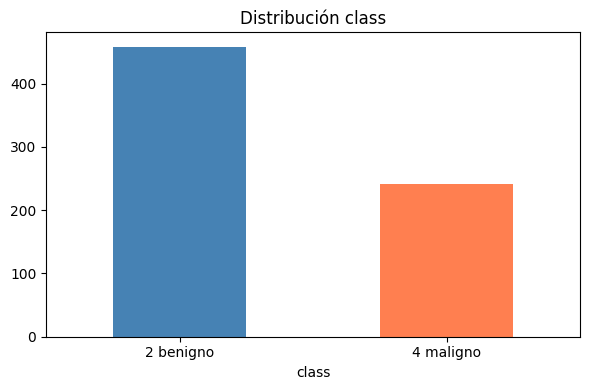

In [28]:
plt.figure(figsize=(6,4))
df['class'].value_counts().sort_index().plot(kind='bar', color=['steelblue','coral'])
plt.title('Distribución class')
plt.xticks([0,1], ['2 benigno','4 maligno'], rotation=0)
plt.tight_layout(); plt.show()


In [29]:
work = df.drop(columns=['sample_code_number']).dropna().copy()
y = (work['class']==4).astype(int).values
X_df = work.drop(columns=['class'])
X = X_df.values.astype(float)

idx=np.random.permutation(len(X))
cut=int(0.75*len(X))
tr,te=idx[:cut],idx[cut:]
X_train,X_test=X[tr],X[te]
y_train,y_test=y[tr],y[te]

mu=X_train.mean(axis=0)
sd=X_train.std(axis=0)
sd[sd==0]=1
X_train=((X_train-mu)/sd).astype(float)
X_test=((X_test-mu)/sd).astype(float)

print('Train/Test:', X_train.shape, X_test.shape)
print('Distribución y_train:', np.bincount(y_train))
print('Distribución y_test :', np.bincount(y_test))


Train/Test: (512, 9) (171, 9)
Distribución y_train: [335 177]
Distribución y_test : [109  62]


In [30]:
def sigmoid(z):
    z=np.clip(z,-500,500)
    return 1/(1+np.exp(-z))

def accuracy(y,p): return np.mean(y==p)
def precision(y,p):
    tp=np.sum((y==1)&(p==1)); fp=np.sum((y==0)&(p==1))
    return 0.0 if (tp+fp)==0 else tp/(tp+fp)
def recall(y,p):
    tp=np.sum((y==1)&(p==1)); fn=np.sum((y==1)&(p==0))
    return 0.0 if (tp+fn)==0 else tp/(tp+fn)
def f1(y,p):
    pr,rc=precision(y,p),recall(y,p)
    return 0.0 if (pr+rc)==0 else 2*pr*rc/(pr+rc)

def train_logistic(X,y,lr=0.05,epochs=2500,l2=1e-4,verbose_every=250):
    w=np.zeros(X.shape[1]); b=0.0
    cost=[]; acc_hist=[]; eps=1e-15
    for epoch in range(1, epochs+1):
        p=sigmoid(X@w+b)
        err=p-y
        dw=(X.T@err)/len(X)+l2*w
        db=err.mean()
        w-=lr*dw; b-=lr*db
        pc=np.clip(p,eps,1-eps)
        c=-(y*np.log(pc)+(1-y)*np.log(1-pc)).mean()+0.5*l2*np.sum(w*w)
        a=accuracy(y,(p>=0.5).astype(int))
        cost.append(c)
        acc_hist.append(a)
        if epoch % verbose_every == 0:
            print(f'Epoch {epoch:4d} | Costo: {c:.4f} | Accuracy(train): {a:.4f}')
    return w,b,cost,acc_hist

w,b,cost_hist,acc_hist = train_logistic(X_train,y_train,lr=0.05,epochs=2500,l2=1e-4,verbose_every=250)
yp = (sigmoid(X_test@w+b)>=0.5).astype(int)

print('Métricas en TEST')
print('Accuracy :', round(accuracy(y_test,yp),4))
print('Precision:', round(precision(y_test,yp),4))


Epoch  250 | Costo: 0.0938 | Accuracy(train): 0.9746
Epoch  500 | Costo: 0.0834 | Accuracy(train): 0.9746
Epoch  750 | Costo: 0.0799 | Accuracy(train): 0.9746
Epoch 1000 | Costo: 0.0781 | Accuracy(train): 0.9727
Epoch 1250 | Costo: 0.0771 | Accuracy(train): 0.9727
Epoch 1500 | Costo: 0.0764 | Accuracy(train): 0.9727
Epoch 1750 | Costo: 0.0759 | Accuracy(train): 0.9727
Epoch 2000 | Costo: 0.0755 | Accuracy(train): 0.9746
Epoch 2250 | Costo: 0.0753 | Accuracy(train): 0.9746
Epoch 2500 | Costo: 0.0751 | Accuracy(train): 0.9746
Métricas en TEST
Accuracy : 0.9649
Precision: 0.9516


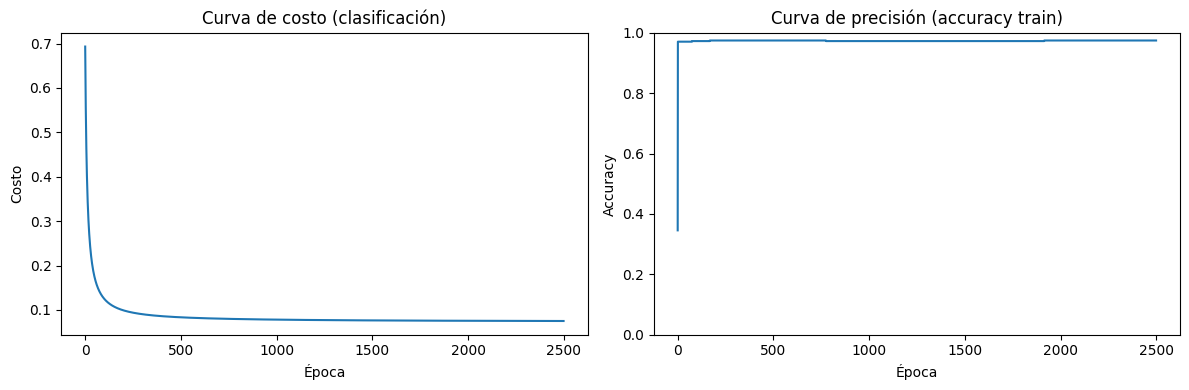

In [31]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(cost_hist)
plt.title('Curva de costo (clasificación)')
plt.xlabel('Época'); plt.ylabel('Costo')

plt.subplot(1,2,2)
plt.plot(acc_hist)
plt.title('Curva de precisión (accuracy train)')
plt.xlabel('Época'); plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.tight_layout(); plt.show()


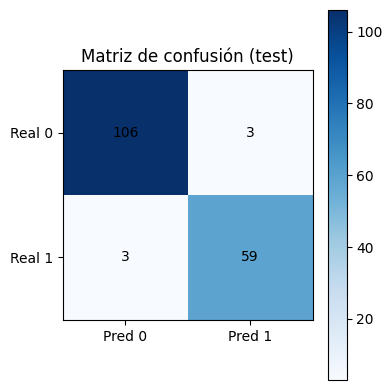

In [32]:
TP=np.sum((y_test==1)&(yp==1))
TN=np.sum((y_test==0)&(yp==0))
FP=np.sum((y_test==0)&(yp==1))
FN=np.sum((y_test==1)&(yp==0))
cm=np.array([[TN,FP],[FN,TP]])

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j],ha='center',va='center')
plt.xticks([0,1], ['Pred 0','Pred 1'])
plt.yticks([0,1], ['Real 0','Real 1'])
plt.title('Matriz de confusión (test)')
plt.colorbar(); plt.tight_layout(); plt.show()


## Descripción del proceso realizado
1. Carga y limpieza del dataset (eliminación de ID y adapatacion de a la tarea).
2. Definición del target binario (class=4 -> 1, class=2 -> 0).
3. Estandarización de features usando solo estadísticas de entrenamiento.
4. Entrenamiento con regresión logística por descenso del gradiente + regularización L2.
5. Evaluación con Accuracy, Precision y matriz de confusión.

## Explicación final del proyecto

- Se aplicó división 75/25 para medir generalización sobre datos no vistos.
- Se entrenó el modelo con descenso del gradiente, mostrando epocas durante el entrenamiento.
- Se utilizó regularización L2 para reducir sobreajuste.
- Se evaluó el desempeño con métricas pertinentes del problema y visualizaciones de soporte que muestra como la curva llega a su limite, mas o menos en la epoca 1000
- Las curvas permiten verificar convergencia y estabilidad del aprendizaje, las curvas muestran como va el costo va reduciendo a medida que las epocas van aumentando y la curva de precision se muestra horizontal ya que se llego a precion
- En la matriz de confusion se puede apreciar que el error es minimo, mostrando una confusion muy baja con tan solo 3-3 de confusion para cada clasificaion
